Explorining Spatial Tuning in GridWorld RNN

Results observation: The RNN developed location dependent hidden activity, with 15 units out of 128 obtaining an %EV above 0.5. In addition, the activation zones in the grid of each neuron does further support the idea that they are most active for specific zones. 

In [1]:
%load_ext autoreload
%autoreload 2

Imports

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
from IPython.display import display, Markdown
import functions.trajectories as trajectories
import functions.NN_models as NN_models
import functions.gridworld as gridworld
import functions.model_training_evaluator as model_training_evaluator
import functions.dataset_generator as dataset_generator
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/seblee/miniconda3/envs/main/bin/python
2.14.0+cu130


State variables

In [3]:

HEIGHT = 29
WIDTH = 36
VIEW_SIZE = 5

START_X = 7
START_Y = 7
START_DIRECTION = 2
RANDOM_START = True

N_STEPS = 500
N_TRAJ = 20

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]
ACTION_PROBS_TURN_HEAVY = [0.3, 0.35, 0.35, 0.0]


TRAINER_MOVE_SEED = 100
TRAINER_START_SEED = 150
VALIDATOR_MOVE_SEED = 300
VALIDATOR_START_SEED = 350

STUNING_START_SEED_1 = 5
STUNING_MOVE_SEED_1 = 10
STUNING_START_SEED_2 = 6
STUNING_MOVE_SEED_2 = 11

TRAINING_EPOCHS = 3000

HIDDEN_SIZE = 128     

Gridworld Creation

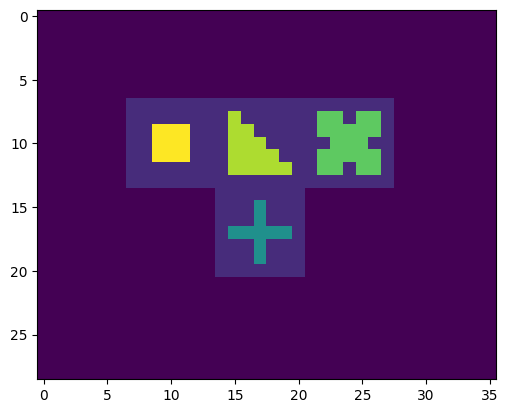

In [4]:
grid = gridworld.GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(7, 14, 7, 28)
grid.add_rectangle_region(14, 21, 14, 21)
grid.add_square_shape(9, 9, 3, 7)
grid.add_triangle_shape(8, 15, 5, 0, 6)
grid.add_square_shape(9, 23, 3, 5)
grid.add_square_shape(8, 22, 2, 5)
grid.add_square_shape(11, 22, 2, 5)
grid.add_square_shape(11, 25, 2, 5)
grid.add_square_shape(8, 25, 2, 5)
grid.add_rectangle_shape(15, 17, 5, 1, 3)
grid.add_rectangle_shape(17, 15, 1, 5, 3)
plt.imshow(grid.grid)


NN Training and Validation

RNN Trainer final loss: 0.585598886013031
RNN Validator final loss: 0.9905049800872803


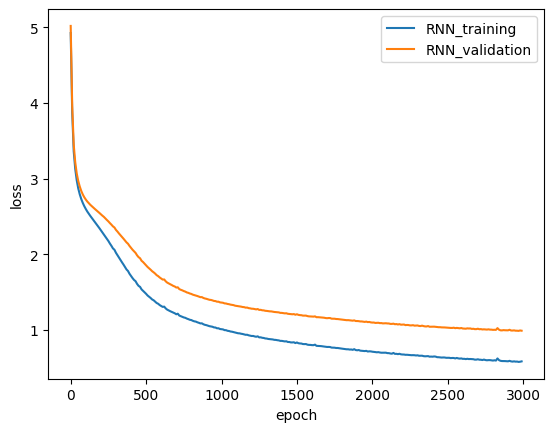

4.713525295257568

In [5]:


#Generate trainer and validator agents
trainer_inputs_stack, trainer_target_stack, trainer_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, N_TRAJ, TRAINER_MOVE_SEED, random_start=RANDOM_START, start_seed_start=TRAINER_START_SEED)
validator_inputs_stack, validator_target_stack, validator_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, 30, VALIDATOR_MOVE_SEED, random_start=RANDOM_START, start_seed_start=VALIDATOR_START_SEED)


INPUT_SIZE = trainer_inputs_stack.shape[2]
OUTPUT_SIZE = trainer_target_stack.shape[2]

#Train RNN

model_RNN = NN_models.BasicRNN(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
RNN_loss_info = model_training_evaluator.model_training(model_RNN, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack, TRAINING_EPOCHS)
print(f"RNN Trainer final loss: {RNN_loss_info[1][-1]}")
print(f"RNN Validator final loss: {RNN_loss_info[2][-1]}")

model_training_evaluator.plot_training_result(RNN_loss_info, "epoch", "loss", "RNN_training", "RNN_validation")

#Baseline Loss Evaluation

model_training_evaluator.baseline_evaluation(trainer_inputs_stack, trainer_target_stack)
model_training_evaluator.baseline_evaluation(validator_inputs_stack, validator_target_stack)



Validator Error per Action Type

In [6]:
results_array = []

trainer_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, trainer_inputs_stack, trainer_target_stack)
validator_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, validator_inputs_stack, validator_target_stack)

results_array.append(trainer_RNN_action_losses)
results_array.append(validator_RNN_action_losses)

results = pd.DataFrame(
    results_array,
    index = ["trainer, RNN", "validator, RNN"],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results

,Forward,Left,Right,Stop
"trainer, RNN",0.266401,1.143434,1.108657,0.805013
"validator, RNN",0.462994,1.996252,1.976747,1.185504


Spatial tuning analysis: Trajectory creation

In [7]:
def generate_spatial_tuning(move_seed, start_seed, average=True):
    stuning_inputs_stack, stuning_target_stack, stuning_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, 3000, 50, move_seed, random_start=RANDOM_START, start_seed_start=start_seed)
    
    model_RNN.eval()
    with torch.no_grad():
        # all hidden states: NTRAJ X NSTEPS X N_HIDDEN sized torch tensor
        all_hidden_states = model_RNN.get_hidden_states(stuning_inputs_stack)

    # all_positions_directions = NTRAJ X NSTEPS X (x, y direction) sized python array
    all_positions_directions = []

    for agents in stuning_agent_list:
        positions_directions = agents.states[1:]
        all_positions_directions.append(positions_directions)

    # all_positions_directions = NTRAJ X NSTEPS X (x, y direction) sized torch tensor
    all_positions_directions = torch.tensor(all_positions_directions)

    # hidden_flat = NTRAJ_NSTEPS X N_HIDDEN sized torch tensor
    # states_flat = NTRAJ_NSTEPS X (x, y direction) sized torch tensor
    hidden_flat = all_hidden_states.reshape(-1, HIDDEN_SIZE)
    states_flat = all_positions_directions.reshape(-1, 3)

    # xycoded_states_flat = NTRAJ_NSTEPS X [coded_coords, direction (0 dim torch tensor)] list
    xycoded_states_flat = []
    for x, y, direction in states_flat:
        coded_coords = x * 100 + y
        xycoded_states_flat.append([coded_coords, direction])


    #position_hidden = dict with scalar keys for each position and list of hidden layers, each a torch tensor
    position_hidden_unsorted = {}
    for i in range(len(xycoded_states_flat)):
        position = xycoded_states_flat[i][0].item()
        hidden = hidden_flat[i]

        if position not in position_hidden_unsorted:
            position_hidden_unsorted[position] = []

        position_hidden_unsorted[position].append(hidden)

    position_hidden = dict(sorted(position_hidden_unsorted.items()))

    mean_hidden = []
    positions = []
    for position, neurons in position_hidden.items():
        avg_activation = torch.stack(neurons).mean(dim=0).detach().cpu().numpy()
        mean_hidden.append(avg_activation)
        positions.append(position)

    mean_hidden = np.array(mean_hidden)
    transposed_mean_hidden = mean_hidden.T

    stuning_grid = np.full((HIDDEN_SIZE, HEIGHT, WIDTH), np.nan)

    grid_count = 0
    for neuron in transposed_mean_hidden:
        #print(type(neuron))
        #print(neuron)
        for xyindex in range(len(neuron)):
            xy = positions[xyindex]
            x = xy // 100
            y = xy % 100
            stuning_grid[grid_count, x, y] = neuron[xyindex]
        grid_count += 1
    
    if not average:      
        # convert the positions and hidden neurons dict into a positions X instances X neurons tensor
        activations_per_position = []
        for neurons in position_hidden.values():
            activations_per_position.append(torch.stack(neurons))
        #activations_per_position = torch.stack(activations_per_position)
        return stuning_grid, activations_per_position

    #for i in range(64):
    #
    #    plt.imshow(stuning_grid[i])
    #    plt.colorbar()
    #    plt.savefig(f"grid{i}.png")
    #    plt.show()
        
    return stuning_grid

def spatial_variance_calculator(traj_1_act_tensor, traj_2_tensor):
    traj_1_averaged_act = []    #first traj average neuron i activation list per position
    i = 0
    for pos in traj_1_act_tensor:

        activation = pos.mean(dim = 0)
        #variance = pos.var(dim = 0)
        #print(f"pos {i}: mean = {activation[0]}, variance = {variance[0]}")
        traj_1_averaged_act.append(activation)

    traj_2_tensor_flattened = torch.cat(traj_2_tensor, dim = 0) #tensor
    traj_2_tensor_substracted_act = [] #list of tensors


    for i in range(len(traj_2_tensor)):
        base_mean =  traj_1_averaged_act[i] #assuming that both trajs have the same list and order of positions
        substracted_activation = traj_2_tensor[i] - base_mean
        traj_2_tensor_substracted_act.append(substracted_activation)

    traj_2_tensor_substracted_act_flattened = torch.cat(traj_2_tensor_substracted_act, dim = 0) #tensor

    neuron_base_variance = torch.var(traj_2_tensor_flattened, dim = 0)
    neuron_substracted_variance = torch.var(traj_2_tensor_substracted_act_flattened, dim = 0)

    explained_variance = (1 - (neuron_substracted_variance / neuron_base_variance))
    #print(traj_2_tensor_substracted_act.shape)
    #print(neuron_base_variance)
    #print(neuron_substracted_variance)


    return explained_variance

    



In [8]:
stuning_grid_1, traj_1_act_list = generate_spatial_tuning(5, 10, False)
stuning_grid_2, traj_2_act_list = generate_spatial_tuning(6, 11, False)

In [9]:

explained_variance = spatial_variance_calculator(traj_1_act_list, traj_2_act_list)
#explained_variance_self = spatial_variance_calculator(traj_1_act_list, traj_1_act_list)

print(explained_variance)
spatial_neuron_index = []
spatial_neuron_ev = []
i = 0
for ev in explained_variance:
    if ev > 0.5:
        spatial_neuron_index.append(i)
        spatial_neuron_ev.append(ev.item())
        print(f"Neuron {i}: {ev} %EV")
    i += 1
    



tensor([0.0362, 0.1047, 0.1074, 0.0803, 0.2126, 0.1896, 0.0933, 0.0780, 0.1516,
        0.2042, 0.5108, 0.2810, 0.2791, 0.0314, 0.1094, 0.2140, 0.2844, 0.1125,
        0.1284, 0.1384, 0.3697, 0.1698, 0.1636, 0.1910, 0.2527, 0.1118, 0.2572,
        0.3937, 0.3498, 0.2105, 0.1291, 0.2190, 0.3724, 0.0543, 0.0401, 0.4005,
        0.1772, 0.1298, 0.2695, 0.6020, 0.0745, 0.6023, 0.7027, 0.4956, 0.1837,
        0.2284, 0.0928, 0.3690, 0.1737, 0.1308, 0.1779, 0.0480, 0.2809, 0.4758,
        0.1625, 0.4865, 0.2490, 0.6763, 0.3656, 0.1698, 0.5196, 0.4417, 0.4842,
        0.3750, 0.2288, 0.1672, 0.6147, 0.1837, 0.1173, 0.2772, 0.2396, 0.1028,
        0.1380, 0.5812, 0.1669, 0.1671, 0.5706, 0.0744, 0.0519, 0.5911, 0.3563,
        0.0219, 0.0700, 0.2815, 0.2540, 0.1337, 0.1551, 0.4117, 0.4922, 0.6715,
        0.2023, 0.5650, 0.4392, 0.1253, 0.1227, 0.1028, 0.1679, 0.1202, 0.6564,
        0.3417, 0.0782, 0.2627, 0.2838, 0.1096, 0.2374, 0.3900, 0.1358, 0.0706,
        0.2721, 0.1783, 0.0567, 0.4341, 

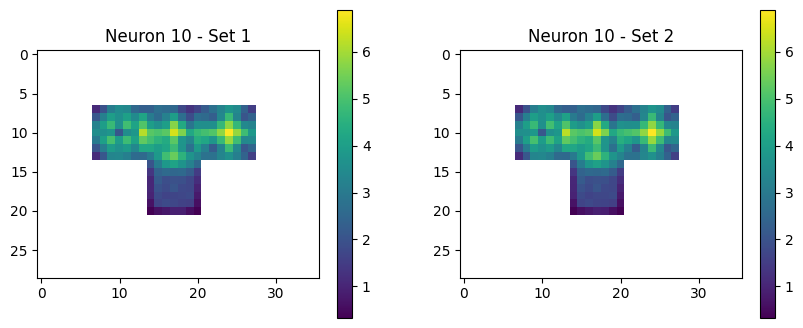

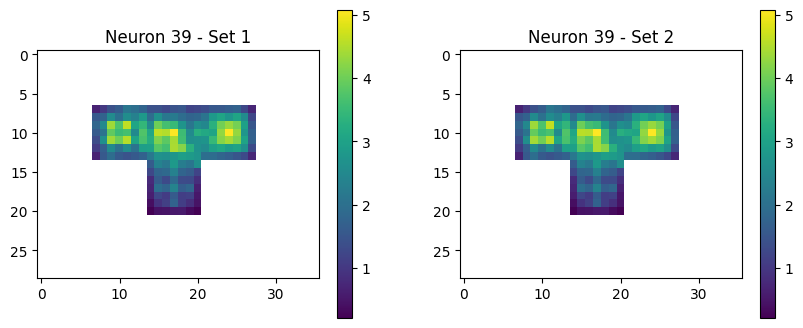

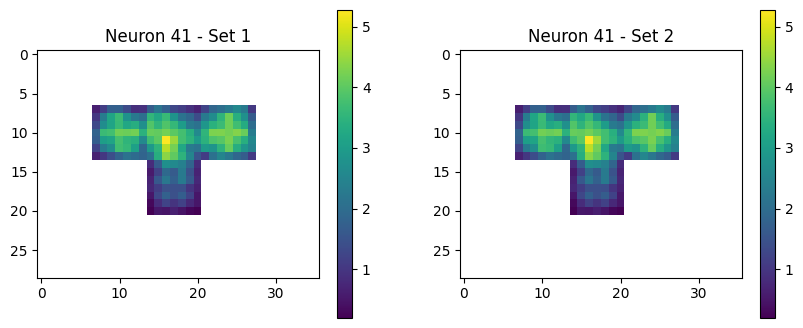

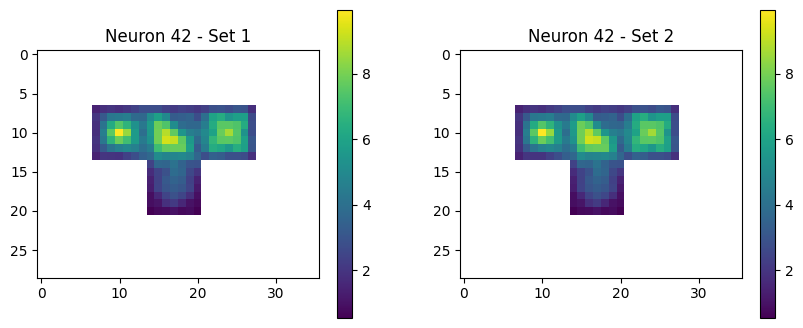

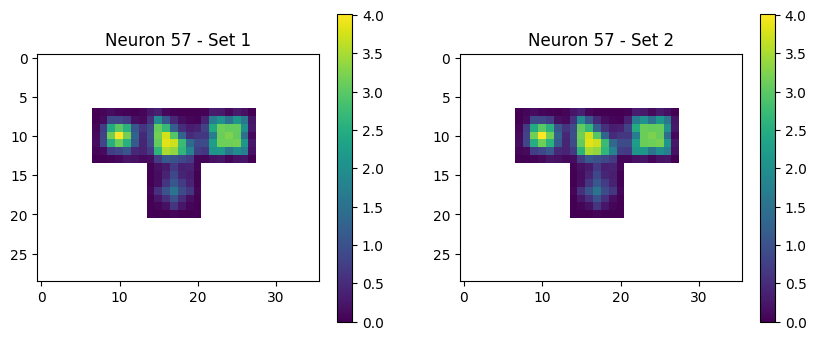

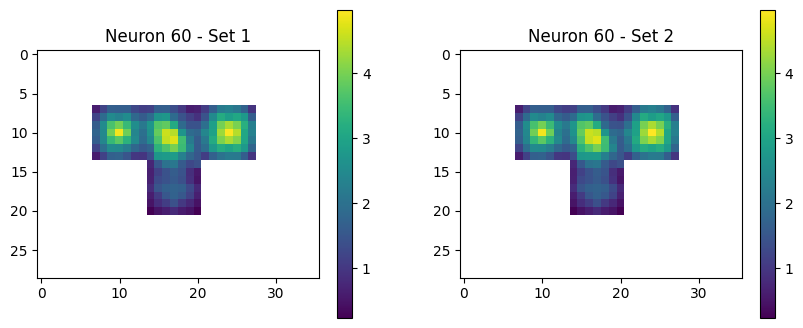

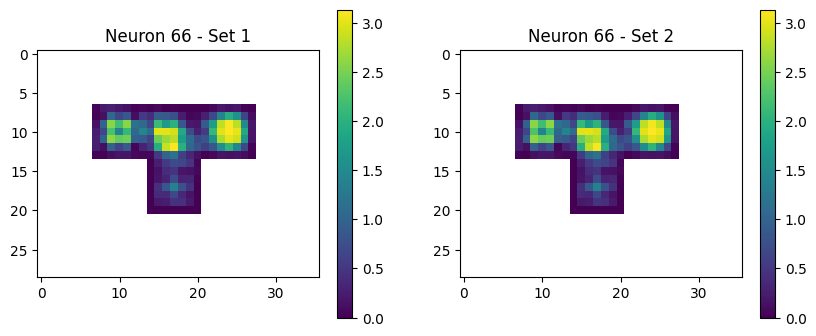

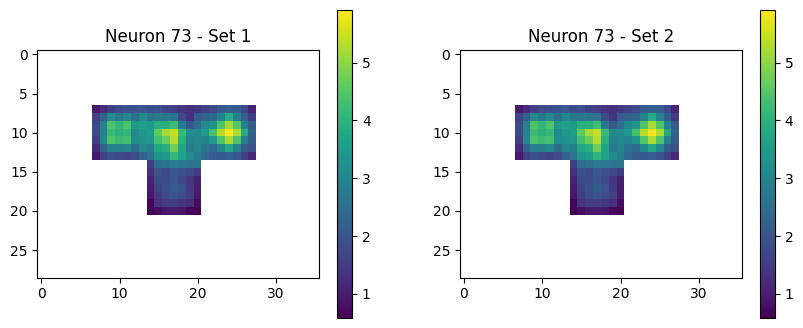

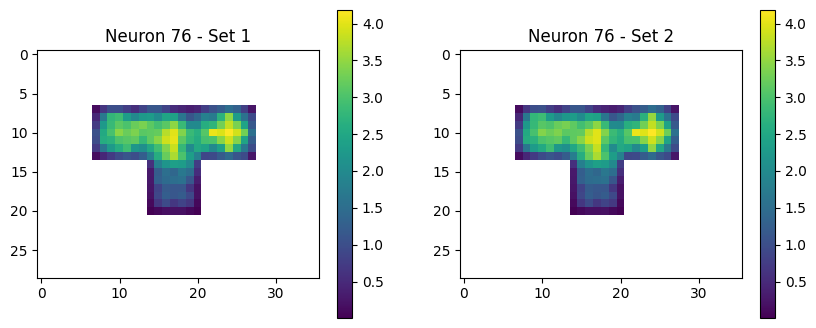

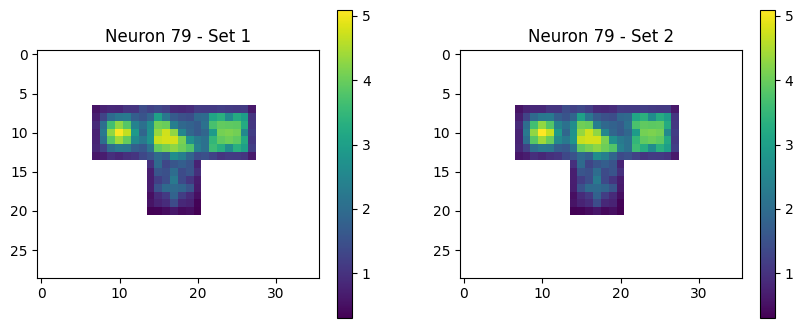

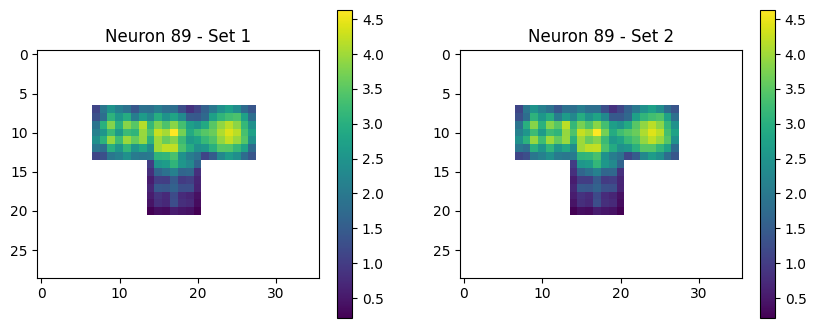

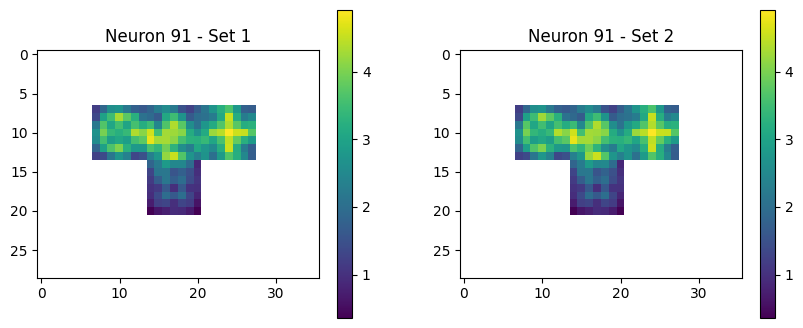

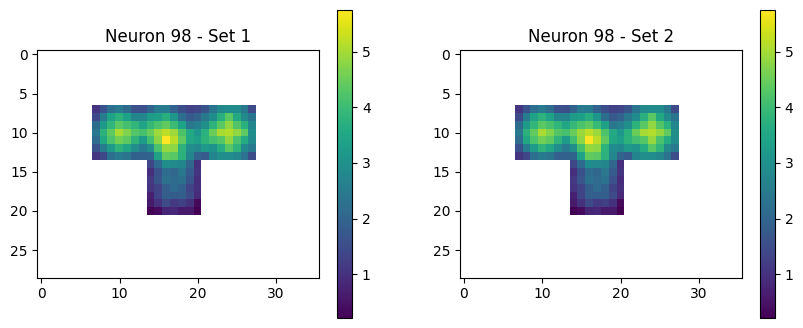

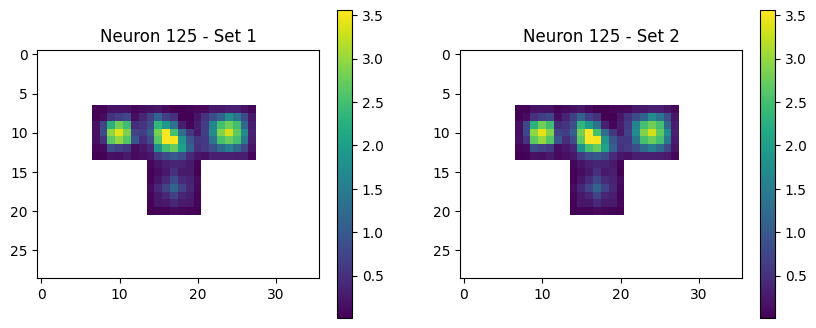

In [10]:

for i in spatial_neuron_index:
    fig, ax = plt.subplots(1, 2, figsize = (10, 4))

    vmin = min(np.nanmin(stuning_grid_1[i]), np.nanmin(stuning_grid_2[i]))
    vmax = max(np.nanmax(stuning_grid_1[i]), np.nanmax(stuning_grid_2[i]))

    im1 = ax[0].imshow(stuning_grid_1[i], vmin=vmin, vmax=vmax)
    ax[0].set_title(f"Neuron {i} - Set 1")
    fig.colorbar(im1, ax=ax[0])

    im2 = ax[1].imshow(stuning_grid_2[i], vmin=vmin, vmax=vmax)
    ax[1].set_title(f"Neuron {i} - Set 2")
    fig.colorbar(im2, ax=ax[1])
    plt.show()